Project Title : International Debt Analysis

In [1]:
!pip install pandas

In [2]:
pip install pandas sqlalchemy psycopg2

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


FILE LOAD

In [4]:
files = {
    "df_Countryseries": "Country-Series - Metadata.csv",
    "df_allcountry": "IDS_ALLCountries_Data.csv",
    "df_CountryMetaData": "IDS_CountryMetaData.csv",
    "df_FootNote":  "IDS_FootNoteMetaData.csv",
    "df_SeriesMeta": "IDS_SeriesMetaData.csv",
}

dfs= {}

for name, fname in files.items():
    dfs[name] = pd.read_csv(fname, low_memory=False, encoding='latin1')
    print(f" Loaded: {name}  →  {dfs[name].shape}")

 Loaded: df_Countryseries  →  (375, 4)
 Loaded: df_allcountry  →  (62983, 39)
 Loaded: df_CountryMetaData  →  (134, 30)
 Loaded: df_FootNote  →  (2673, 5)
 Loaded: df_SeriesMeta  →  (574, 12)


SHAPE & COLUMNS

In [5]:
for name, df in dfs.items():
    print(f"\n{'='*55}")
    print(f" {name}")
    print(f"   Shape   : {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"   Columns : {list(df.columns)}")


 df_Countryseries
   Shape   : 375 rows × 4 cols
   Columns : ['Type', 'Country Code', 'Series Code', 'Description']

 df_allcountry
   Shape   : 62,983 rows × 39 cols
   Columns : ['Country Name', 'Country Code', 'Counterpart-Area Name', 'Counterpart-Area Code', 'Series Name', 'Series Code', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026', '2027', '2028', '2029', '2030', '2031', '2032']

 df_CountryMetaData
   Shape   : 134 rows × 30 cols
   Columns : ['Code', 'Long Name', 'Income Group', 'Region', 'Lending category', 'Other groups', 'Currency Unit', 'Latest population census', 'Latest household survey', 'Special Notes', 'National accounts base year', 'National accounts reference year', 'System of National Accounts', 'SNA price valuation', 'PPP survey years', 'Balance of Payments Manual in use', 'External debt Reporting

DATA TYPE

In [6]:
for name, df in dfs.items():
    print(f"\n{'='*55}")
    print(f" Data Types — {name}")
    print(df.dtypes.to_string())


 Data Types — df_Countryseries
Type            object
Country Code    object
Series Code     object
Description     object

 Data Types — df_allcountry
Country Name              object
Country Code              object
Counterpart-Area Name     object
Counterpart-Area Code     object
Series Name               object
Series Code               object
2000                     float64
2001                     float64
2002                     float64
2003                     float64
2004                     float64
2005                     float64
2006                     float64
2007                     float64
2008                     float64
2009                     float64
2010                     float64
2011                     float64
2012                     float64
2013                     float64
2014                     float64
2015                     float64
2016                     float64
2017                     float64
2018                     float64
2019                  

MISSING  COUNT & MISSING % VALUE

In [7]:
for name, df in dfs.items():
    print(f"\n{'='*55}")
    print(f" Missing Values — {name}")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    miss_df = miss_df[miss_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    if miss_df.empty:
        print(" No missing values!")
    else:
        print(miss_df.to_string())


 Missing Values — df_Countryseries
 No missing values!

 Missing Values — df_allcountry
                       Missing Count  Missing %
2032                           51417      81.64
2031                           51212      81.31
2030                           51016      81.00
2029                           50845      80.73
2028                           50551      80.26
2027                           50361      79.96
2026                           50223      79.74
2025                           50128      79.59
2003                           13982      22.20
2012                           13975      22.19
2011                           13903      22.07
2005                           13846      21.98
2004                           13788      21.89
2002                           13721      21.79
2013                           13604      21.60
2006                           13589      21.58
2001                           13549      21.51
2000                           13493      21.42

DUPLICATE CHECKING & REMOVING DUPLICATE ROWS

In [8]:
print(
    dfs["df_allcountry"].duplicated().sum()
)


2


In [9]:
duplicates = dfs["df_allcountry"][dfs["df_allcountry"].duplicated()]
duplicates.head()

,Country Name,Country Code,Counterpart-Area Name,Counterpart-Area Code,Series Name,Series Code,2000,2001,2002,2003,...,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032
62979,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
dfs["df_allcountry"].tail()

,Country Name,Country Code,Counterpart-Area Name,Counterpart-Area Code,Series Name,Series Code,2000,2001,2002,2003,...,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032
62978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62979,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62981,Data from database: International Debt Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62982,Last Updated: 12/03/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
dfs["df_allcountry"] = dfs["df_allcountry"].dropna(how="all")


In [12]:
dfs["df_allcountry"] = dfs["df_allcountry"][
    dfs["df_allcountry"]["Country Code"].notna()]

In [13]:
dfs["df_allcountry"].tail()

,Country Name,Country Code,Counterpart-Area Name,Counterpart-Area Code,Series Name,Series Code,2000,2001,2002,2003,...,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032
62973,Zimbabwe,ZWE,World,WLD,"Undisbursed external debt, official creditors ...",DT.UND.OFFT.CD,9.522543e+08,672610306.0,441652353.0,472182506.5,...,7.647331e+08,6.881084e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62974,Zimbabwe,ZWE,World,WLD,"Undisbursed external debt, private creditors (...",DT.UND.PRVT.CD,9.075099e+07,69734880.0,53506702.8,35241540.6,...,6.657338e+06,6.350490e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62975,Zimbabwe,ZWE,World,WLD,"Undisbursed external debt, total (UND, current...",DT.UND.DPPG.CD,1.043005e+09,742345186.0,495159055.8,507424047.1,...,7.713904e+08,6.944589e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62976,Zimbabwe,ZWE,World,WLD,"Use of IMF credit (DOD, current US$)",DT.DOD.DIMF.US.CD,2.806598e+08,261951544.4,280246014.7,301553836.0,...,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62977,Zimbabwe,ZWE,World,WLD,"Use of IMF credit and SDR allocations (DOD, cu...",DT.DOD.DIMF.CD,2.939495e+08,274770190.4,294113118.7,316710730.0,...,1.363159e+09,1.325023e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


FUTURE YEAR DROP(2025 TO 2032) AND IRRELVANT COLUMNS


In [14]:
dfs["df_allcountry"] = dfs["df_allcountry"].drop(
    columns=[
        "2025",
        "2026",
        "2027",
        "2028",
        "2029",
        "2030",
        "2031",
        "2032"
    ],
    errors="ignore"
)

In [15]:
dfs["df_allcountry"].columns

Index(['Country Name', 'Country Code', 'Counterpart-Area Name',
       'Counterpart-Area Code', 'Series Name', 'Series Code', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019',
       '2020', '2021', '2022', '2023', '2024'],
      dtype='object')

In [16]:
dfs["df_allcountry"] = dfs["df_allcountry"].drop(
    columns=[
        "Counterpart-Area Name",
        "Counterpart-Area Code"
    ],
    errors="ignore"
)

In [17]:
print(dfs["df_allcountry"].columns.tolist())

['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


In [18]:
dfs["df_allcountry"]

,Country Name,Country Code,Series Name,Series Code,2000,2001,2002,2003,2004,2005,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.DPPG,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.000000e+00,1.983560e+01,0.000000e+00,1.790410e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.OFFT,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.000000e+00,1.983560e+01,0.000000e+00,1.790410e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.PRVT,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,Afghanistan,AFG,Average grant element on new external debt com...,DT.GRE.DPPG,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.000000e+00,6.426460e+01,0.000000e+00,7.307900e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,Afghanistan,AFG,Average grant element on new external debt com...,DT.GRE.OFFT,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.000000e+00,6.426460e+01,0.000000e+00,7.307900e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62973,Zimbabwe,ZWE,"Undisbursed external debt, official creditors ...",DT.UND.OFFT.CD,9.522543e+08,672610306.0,441652353.0,472182506.5,381463289.9,264801978.8,...,729104062.9,1.514764e+09,1.410143e+09,1.288291e+09,1.300964e+09,1.264977e+09,1.092422e+09,7.987799e+08,7.647331e+08,6.881084e+08
62974,Zimbabwe,ZWE,"Undisbursed external debt, private creditors (...",DT.UND.PRVT.CD,9.075099e+07,69734880.0,53506702.8,35241540.6,33858170.8,25905254.2,...,11367395.3,9.216350e+06,6.573758e+06,6.395567e+06,6.384398e+06,6.806978e+06,6.528428e+06,6.363256e+06,6.657338e+06,6.350490e+06
62975,Zimbabwe,ZWE,"Undisbursed external debt, total (UND, current...",DT.UND.DPPG.CD,1.043005e+09,742345186.0,495159055.8,507424047.1,415321460.7,290707233.0,...,740471458.2,1.523981e+09,1.416717e+09,1.294687e+09,1.307348e+09,1.271784e+09,1.098951e+09,8.051432e+08,7.713904e+08,6.944589e+08
62976,Zimbabwe,ZWE,"Use of IMF credit (DOD, current US$)",DT.DOD.DIMF.US.CD,2.806598e+08,261951544.4,280246014.7,301553836.0,293206735.0,110506868.6,...,86585989.4,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


CONVERTING WIDER COLUMN TO LONG FORMAT USING MELT

In [19]:
df_long = dfs["df_allcountry"].melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Series Name",
        "Series Code"
    ],
    var_name="Year",
    value_name="Debt"
)

STRIPING EXTRA SPACE

In [20]:
df_long["Country Code"] = df_long["Country Code"].str.strip()

In [21]:
df_long.head()

,Country Name,Country Code,Series Name,Series Code,Year,Debt
0,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.DPPG,2000,NaN
1,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.OFFT,2000,NaN
2,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.PRVT,2000,NaN
3,Afghanistan,AFG,Average grant element on new external debt com...,DT.GRE.DPPG,2000,NaN
4,Afghanistan,AFG,Average grant element on new external debt com...,DT.GRE.OFFT,2000,NaN


In [22]:
df_long.tail()

,Country Name,Country Code,Series Name,Series Code,Year,Debt
1574445,Zimbabwe,ZWE,"Undisbursed external debt, official creditors ...",DT.UND.OFFT.CD,2024,6.881084e+08
1574446,Zimbabwe,ZWE,"Undisbursed external debt, private creditors (...",DT.UND.PRVT.CD,2024,6.350490e+06
1574447,Zimbabwe,ZWE,"Undisbursed external debt, total (UND, current...",DT.UND.DPPG.CD,2024,6.944589e+08
1574448,Zimbabwe,ZWE,"Use of IMF credit (DOD, current US$)",DT.DOD.DIMF.US.CD,2024,0.000000e+00
1574449,Zimbabwe,ZWE,"Use of IMF credit and SDR allocations (DOD, cu...",DT.DOD.DIMF.CD,2024,1.325023e+09


In [23]:
df_long['Debt'].isna().sum()

np.int64(327515)

In [24]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1574450 entries, 0 to 1574449
Data columns (total 6 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Country Name  1574450 non-null  object 
 1   Country Code  1574450 non-null  object 
 2   Series Name   1574450 non-null  object 
 3   Series Code   1574450 non-null  object 
 4   Year          1574450 non-null  object 
 5   Debt          1246935 non-null  float64
dtypes: float64(1), object(5)
memory usage: 72.1+ MB


In [25]:
df_long.describe()

,Debt
count,1.246935e+06
mean,9.873517e+09
std,2.147381e+11
min,-5.270000e+11
25%,3.018800e+00
50%,1.812543e+07
75%,4.312734e+08
max,3.820000e+13


In [26]:
df_long.sample(10)

,Country Name,Country Code,Series Name,Series Code,Year,Debt
288928,Mauritania,MRT,"PPG, official creditors (AMT, current US$)",DT.AMT.OFFT.CD,2004,2.419611e+07
656888,Iraq,IRQ,"External debt stocks, total (DOD, current US$)",DT.DOD.DECT.CD,2010,NaN
884682,Azerbaijan,AZE,Interest rescheduled (capitalized) (current US$),DT.IXR.DPPG.CD,2014,0.000000e+00
781439,India,IND,"IMF credit and SDR allocations, charges (INT, ...",DT.INT.DIMF.CD,2012,1.828063e+06
801586,Paraguay,PRY,"PPG, bilateral concessional (AMT, current US$)",DT.AMT.BLTC.CD,2012,3.762200e+06
1554582,Niger,NER,"Currency composition of PPG debt, SDR (%)",DT.CUR.SDRW.ZS,2024,2.213000e+00
1070219,Zimbabwe,ZWE,"Disbursements on external debt, long-term (DIS...",DT.DIS.DLXF.CD,2016,1.135728e+09
896993,Ecuador,ECU,"GG, multilateral (TDS, current US$)",DT.TDS.MLAT.GG.CD,2014,5.936093e+08
1074085,Bangladesh,BGD,Interest rescheduled (capitalized) (current US$),DT.IXR.DPPG.CD,2017,NaN
988656,Nigeria,NGA,"PS, bilateral (DOD, current US$)",DT.DOD.BLAT.PS.CD,2015,1.682696e+09


In [27]:
df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce")

In [28]:
df_long.dtypes

,0
Country Name,object
Country Code,object
Series Name,object
Series Code,object
Year,int64
Debt,float64


HANDLING MISSING VALUE

In [29]:
df_long["Debt"].isna().sum()

np.int64(327515)

In [30]:
(df_long["Debt"].isna().mean()) * 100

np.float64(20.80186731874623)

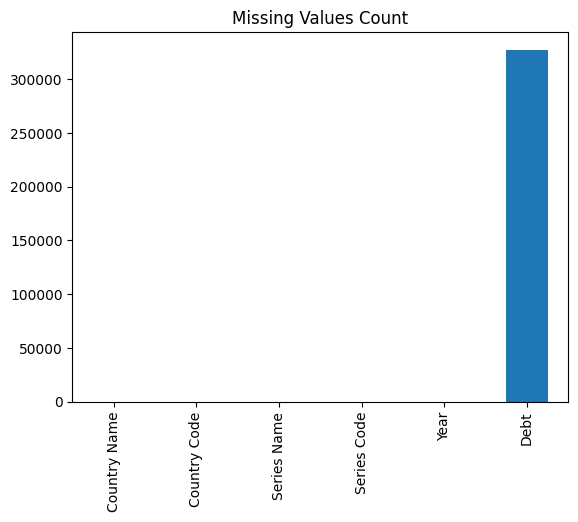

In [31]:
df_long.isnull().sum().plot(kind ='bar')
plt.title("Missing Values Count")
plt.show()

In [32]:
df_long.shape

(1574450, 6)

CHECKING EMPTY CELL DEBT VALUE FROM YEAR 2000 TO 20024 FOR EXECUTING NULL VALUE HANDLING

In [33]:
df_check = df_long[
    (df_long["Year"] >= 2000) &
    (df_long["Year"] <= 2024)
]

In [34]:
all_null_groups = (
    df_check
    .groupby(["Country Name", "Series Code"])["Debt"]
    .apply(lambda x: x.isna().all())
)

In [35]:
no_data_series = all_null_groups[all_null_groups]

no_data_series

Country Name  Series Code                   
Albania       DT.AMT.PROP.CB.CD                 True
              DT.AMT.PROP.OPS.CD                True
              DT.AMT.PRVT.CB.CD                 True
              DT.DIS.PROP.CB.CD                 True
              DT.DIS.PRVT.CB.CD                 True
                                                ... 
Zimbabwe      DT.NTR.PRPG.CD                    True
              DT.NTR.PRVT.PRVG.CD               True
              DT.TDS.PROP.PRVG.CD               True
              DT.TDS.PRPG.CD                    True
              DT.TDS.PRVT.PRVG.CD               True
Name: Debt, Length: 3480, dtype: bool

In [36]:
no_data_rows = df_check.merge(
    no_data_series.reset_index()[["Country Name", "Series Code"]],
    on=["Country Name", "Series Code"],
    how="inner"
)

no_data_rows.head()

,Country Name,Country Code,Series Name,Series Code,Year,Debt
0,Albania,ALB,"CB, other private creditors (AMT, current US$)",DT.AMT.PROP.CB.CD,2000,NaN
1,Albania,ALB,"CB, other private creditors (DIS, current US$)",DT.DIS.PROP.CB.CD,2000,NaN
2,Albania,ALB,"CB, other private creditors (DOD, current US$)",DT.DOD.PROP.CB.CD,2000,NaN
3,Albania,ALB,"CB, other private creditors (INT, current US$)",DT.INT.PROP.CB.CD,2000,NaN
4,Albania,ALB,"CB, other private creditors (NFL, current US$)",DT.NFL.PROP.CB.CD,2000,NaN


In [37]:
no_data_rows

,Country Name,Country Code,Series Name,Series Code,Year,Debt
0,Albania,ALB,"CB, other private creditors (AMT, current US$)",DT.AMT.PROP.CB.CD,2000,NaN
1,Albania,ALB,"CB, other private creditors (DIS, current US$)",DT.DIS.PROP.CB.CD,2000,NaN
2,Albania,ALB,"CB, other private creditors (DOD, current US$)",DT.DOD.PROP.CB.CD,2000,NaN
3,Albania,ALB,"CB, other private creditors (INT, current US$)",DT.INT.PROP.CB.CD,2000,NaN
4,Albania,ALB,"CB, other private creditors (NFL, current US$)",DT.NFL.PROP.CB.CD,2000,NaN
...,...,...,...,...,...,...
86995,Zimbabwe,ZWE,"PRVG, private creditors (AMT, current US$)",DT.AMT.PRVT.PRVG.CD,2024,NaN
86996,Zimbabwe,ZWE,"PRVG, private creditors (INT, current US$)",DT.INT.PRVT.PRVG.CD,2024,NaN
86997,Zimbabwe,ZWE,"PRVG, private creditors (NFL, current US$)",DT.NFL.PRVT.PRVG.CD,2024,NaN
86998,Zimbabwe,ZWE,"PRVG, private creditors (NTR, current US$)",DT.NTR.PRVT.PRVG.CD,2024,NaN


In [38]:
algeria_no_data = no_data_series.loc["Algeria"]

algeria_no_data

,Debt
Series Code,
DT.AMT.PBND.CD,True
DT.AMT.PBND.OPS.CD,True
DT.AMT.PBND.PS.CD,True
DT.DOD.PBND.CD,True
DT.DOD.PBND.OPS.CD,True
DT.DOD.PBND.PS.CD,True
DT.INT.PBND.CD,True
DT.INT.PBND.OPS.CD,True
DT.INT.PBND.PS.CD,True


In [39]:
null_check = (
    df_long
    .groupby(["Country Name", "Series Code"])["Debt"]
    .count()
)

In [40]:
null_check

Country Name  Series Code      
Afghanistan   BM.GSR.TOTL.CD       13
              BN.CAB.XOKA.CD       15
              BX.GRT.EXTA.CD.DT    18
              BX.GRT.TECH.CD.DT    18
              BX.GSR.TOTL.CD       13
                                   ..
Zimbabwe      FI.RES.TOTL.CD       25
              FI.RES.TOTL.DT.ZS    25
              FI.RES.TOTL.MO       15
              NY.GNP.MKTP.CD       25
              SP.POP.TOTL          25
Name: Debt, Length: 62978, dtype: int64

In [41]:
df_long = df_long.sort_values(
    by=["Country Name", "Series Code", "Year"]
)

df_long["Debt"] = (
    df_long
    .groupby(["Country Name", "Series Code"])["Debt"]
    .ffill()

)

In [42]:
df_long

,Country Name,Country Code,Series Name,Series Code,Year,Debt
112,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2000,NaN
63090,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2001,NaN
126068,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2002,NaN
189046,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2003,NaN
252024,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2004,NaN
...,...,...,...,...,...,...
1322343,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2020,15526888.0
1385321,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2021,15797210.0
1448299,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2022,16069056.0
1511277,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2023,16340822.0


In [43]:
df_long = df_long.sort_values(
    by=["Country Name", "Series Code", "Year"]
)

df_long["Debt"] = (
    df_long
    .groupby(["Country Name", "Series Code"])["Debt"]
    .bfill()

)

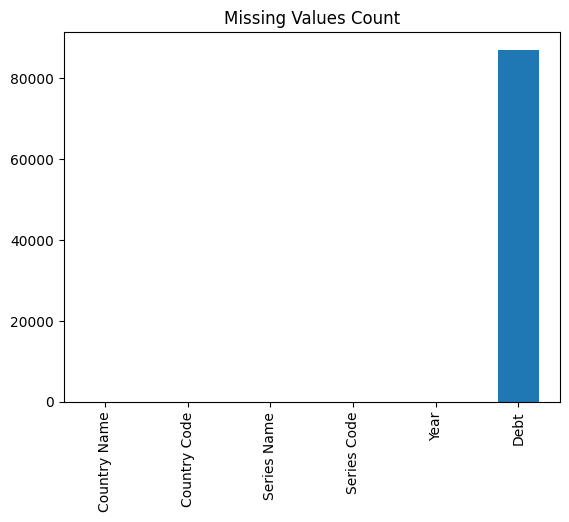

In [44]:
df_long.isnull().sum().plot(kind ='bar')
plt.title("Missing Values Count")
plt.show()

In [45]:
df_long.isnull().sum()

,0
Country Name,0
Country Code,0
Series Name,0
Series Code,0
Year,0
Debt,87000


In [46]:
df_long["Debt"].isna().sum()

np.int64(87000)

In [47]:
print("Total rows:", len(df_long))
print("Null values:", df_long["Debt"].isna().sum())
print("Unique years:", df_long["Year"].nunique())

Total rows: 1574450
Null values: 87000
Unique years: 25


In [48]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1574450 entries, 112 to 1574255
Data columns (total 6 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Country Name  1574450 non-null  object 
 1   Country Code  1574450 non-null  object 
 2   Series Name   1574450 non-null  object 
 3   Series Code   1574450 non-null  object 
 4   Year          1574450 non-null  int64  
 5   Debt          1487450 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 84.1+ MB


In [49]:
df_long.isnull().sum()

,0
Country Name,0
Country Code,0
Series Name,0
Series Code,0
Year,0
Debt,87000


In [50]:
no_data_rows = df_check.merge(
    no_data_series.reset_index()[["Country Name", "Series Code"]],
    on=["Country Name", "Series Code"],
    how="inner"
)

no_data_rows.head()

,Country Name,Country Code,Series Name,Series Code,Year,Debt
0,Albania,ALB,"CB, other private creditors (AMT, current US$)",DT.AMT.PROP.CB.CD,2000,NaN
1,Albania,ALB,"CB, other private creditors (DIS, current US$)",DT.DIS.PROP.CB.CD,2000,NaN
2,Albania,ALB,"CB, other private creditors (DOD, current US$)",DT.DOD.PROP.CB.CD,2000,NaN
3,Albania,ALB,"CB, other private creditors (INT, current US$)",DT.INT.PROP.CB.CD,2000,NaN
4,Albania,ALB,"CB, other private creditors (NFL, current US$)",DT.NFL.PROP.CB.CD,2000,NaN


In [51]:
df_long[
    (df_long["Country Name"] == "Albania") &
    (df_long["Series Code"] == "DT.AMT.PROP.CB.CD")
]["Debt"].isna().all()

np.True_

In [52]:
df_long

,Country Name,Country Code,Series Name,Series Code,Year,Debt
112,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2000,3.873397e+09
63090,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2001,3.873397e+09
126068,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2002,3.873397e+09
189046,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2003,3.873397e+09
252024,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2004,3.873397e+09
...,...,...,...,...,...,...
1322343,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2020,1.552689e+07
1385321,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2021,1.579721e+07
1448299,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2022,1.606906e+07
1511277,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2023,1.634082e+07


In [53]:
df_long.shape

(1574450, 6)

Confirm 87000 null rows

In [54]:
df_long["Debt"].isna().sum()

np.int64(87000)

In [55]:
null_rows = df_long[df_long["Debt"].isna()]

null_rows.head()

,Country Name,Country Code,Series Name,Series Code,Year,Debt
344,Albania,ALB,"CB, other private creditors (AMT, current US$)",DT.AMT.PROP.CB.CD,2000,NaN
63322,Albania,ALB,"CB, other private creditors (AMT, current US$)",DT.AMT.PROP.CB.CD,2001,NaN
126300,Albania,ALB,"CB, other private creditors (AMT, current US$)",DT.AMT.PROP.CB.CD,2002,NaN
189278,Albania,ALB,"CB, other private creditors (AMT, current US$)",DT.AMT.PROP.CB.CD,2003,NaN
252256,Albania,ALB,"CB, other private creditors (AMT, current US$)",DT.AMT.PROP.CB.CD,2004,NaN


In [56]:
len(null_rows)

87000

In [57]:
df_long = df_long.dropna(subset=["Debt"])

In [58]:
df_long

,Country Name,Country Code,Series Name,Series Code,Year,Debt
112,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2000,3.873397e+09
63090,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2001,3.873397e+09
126068,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2002,3.873397e+09
189046,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2003,3.873397e+09
252024,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2004,3.873397e+09
...,...,...,...,...,...,...
1322343,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2020,1.552689e+07
1385321,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2021,1.579721e+07
1448299,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2022,1.606906e+07
1511277,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2023,1.634082e+07


In [59]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1487450 entries, 112 to 1574255
Data columns (total 6 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Country Name  1487450 non-null  object 
 1   Country Code  1487450 non-null  object 
 2   Series Name   1487450 non-null  object 
 3   Series Code   1487450 non-null  object 
 4   Year          1487450 non-null  int64  
 5   Debt          1487450 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 79.4+ MB


In [60]:
df_long.to_csv("Cleaned_ALLCountries_meltone.csv",index=False)

In [61]:
df_long.head(25)

,Country Name,Country Code,Series Name,Series Code,Year,Debt
112,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2000,3.873397e+09
63090,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2001,3.873397e+09
126068,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2002,3.873397e+09
189046,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2003,3.873397e+09
252024,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2004,3.873397e+09
315002,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2005,3.873397e+09
377980,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2006,3.873397e+09
440958,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2007,3.873397e+09
503936,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2008,3.873397e+09
566914,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2009,4.194029e+09


MERGING TWO DATAFRAME df_long with
df_CountryMetaData
---



In [62]:
df_long["Country Code"] = df_long["Country Code"].str.strip().str.upper()
dfs["df_CountryMetaData"]["Code"]= dfs["df_CountryMetaData"]["Code"].str.strip().str.upper()

/tmp/ipykernel_42042/3211948864.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_long["Country Code"] = df_long["Country Code"].str.strip().str.upper()


In [63]:
df_meta = dfs["df_CountryMetaData"][['Code', 'Region', 'Income Group','Lending category','System of trade' ]]

In [64]:
df_meta["Code"]=df_meta["Code"].str.strip().str.upper()

/tmp/ipykernel_42042/1373459503.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_meta["Code"]=df_meta["Code"].str.strip().str.upper()


In [65]:
print(dfs["df_CountryMetaData"].columns.tolist())

['Code', 'Long Name', 'Income Group', 'Region', 'Lending category', 'Other groups', 'Currency Unit', 'Latest population census', 'Latest household survey', 'Special Notes', 'National accounts base year', 'National accounts reference year', 'System of National Accounts', 'SNA price valuation', 'PPP survey years', 'Balance of Payments Manual in use', 'External debt Reporting status', 'System of trade', 'Government Accounting concept', 'IMF data dissemination standard', 'Source of most recent Income and expenditure data', 'Vital registration complete', 'Latest agricultural census', 'Latest industrial data', 'Latest trade data', 'Latest water withdrawal data', '2-alpha code', 'WB-2 code', 'Table Name', 'Short Name']


In [66]:
df_meta

,Code,Region,Income Group,Lending category,System of trade
0,AFG,Middle East & North Africa,Low income,IDA,General trade system
1,ALB,Europe & Central Asia,Upper middle income,IBRD,Special trade system
2,DZA,Middle East & North Africa,Upper middle income,IBRD,Special trade system
3,AGO,Sub-Saharan Africa,Lower middle income,IBRD,General trade system
4,ARG,Latin America & Caribbean,Upper middle income,IBRD,Special trade system
...,...,...,...,...,...
129,VUT,East Asia & Pacific,Lower middle income,IDA,NaN
130,VNM,East Asia & Pacific,Lower middle income,IBRD,General trade system
131,YEM,Middle East & North Africa,Low income,IDA,Special trade system
132,ZMB,Sub-Saharan Africa,Lower middle income,IDA,General trade system


In [67]:
df_meta["Code"].duplicated().sum()

np.int64(0)

In [68]:
df_meta["Code"].nunique()

134

In [69]:
df_long["Country Code"].nunique()

134

In [70]:
df_meta.isnull().sum()

,0
Code,0
Region,14
Income Group,15
Lending category,14
System of trade,34


df_meta["Region"] = df_meta["Region"].fillna("Unknown")
df_meta["Income Group"] = df_meta["Income Group"].fillna("Unknown")

In [71]:
df_meta.isnull().sum()

,0
Code,0
Region,14
Income Group,15
Lending category,14
System of trade,34


In [72]:
df_final = df_long.merge(
    df_meta,
    left_on="Country Code",
    right_on="Code",
    how="inner"
)

In [73]:
df_final.isnull().sum()

,0
Country Name,0
Country Code,0
Series Name,0
Series Code,0
Year,0
Debt,0
Code,0
Region,196950
Income Group,207650
Lending category,196950


In [74]:
df_final.shape

(1487450, 11)

In [75]:
df_final = df_final.dropna(subset=["Region","Income Group","Lending category","System of trade"])

In [76]:
df_final.isnull().sum()

,0
Country Name,0
Country Code,0
Series Name,0
Series Code,0
Year,0
Debt,0
Code,0
Region,0
Income Group,0
Lending category,0


In [77]:
df_final.shape

(1090800, 11)

In [78]:
df_final["Country Name"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Armenia', 'Azerbaijan', 'Bangladesh', 'Belarus', 'Belize',
       'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon',
       'Central African Republic', 'China', 'Colombia', 'Comoros',
       'Congo, Rep.', "Cote d'Ivoire", 'Dominican Republic', 'Ecuador',
       'Egypt, Arab Rep.', 'El Salvador', 'Eswatini', 'Fiji',
       'Gambia, The', 'Georgia', 'Ghana', 'Guatemala', 'Guinea', 'Guyana',
       'Honduras', 'India', 'Indonesia', 'Iran, Islamic Rep.', 'Iraq',
       'Jamaica', 'Jordan', 'Kazakhstan', 'Kenya', 'Kyrgyz Republic',
       'Lao PDR', 'Lebanon', 'Lesotho', 'Madagascar', 'Malawi',
       'Maldives', 'Mali', 'Mauritania', 'Mauritius', 'Mexico', 'Moldova',
       'Mongolia', 'Montenegro', 'Morocco', 'Mozambique', 'Myanmar',
       'Nepal', 'Nicaragua', 'Niger', 'Nigeria', 'North Macedonia',
       'Pakistan', 'Paragu

In [79]:
df_final

,Country Name,Country Code,Series Name,Series Code,Year,Debt,Code,Region,Income Group,Lending category,System of trade
0,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2000,3.873397e+09,AFG,Middle East & North Africa,Low income,IDA,General trade system
1,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2001,3.873397e+09,AFG,Middle East & North Africa,Low income,IDA,General trade system
2,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2002,3.873397e+09,AFG,Middle East & North Africa,Low income,IDA,General trade system
3,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2003,3.873397e+09,AFG,Middle East & North Africa,Low income,IDA,General trade system
4,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2004,3.873397e+09,AFG,Middle East & North Africa,Low income,IDA,General trade system
...,...,...,...,...,...,...,...,...,...,...,...
1487445,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2020,1.552689e+07,ZWE,Sub-Saharan Africa,Lower middle income,Blend,General trade system
1487446,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2021,1.579721e+07,ZWE,Sub-Saharan Africa,Lower middle income,Blend,General trade system
1487447,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2022,1.606906e+07,ZWE,Sub-Saharan Africa,Lower middle income,Blend,General trade system
1487448,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,2023,1.634082e+07,ZWE,Sub-Saharan Africa,Lower middle income,Blend,General trade system


In [80]:
df_final = df_final.drop(columns=["Code"])

In [81]:
df_final.columns

Index(['Country Name', 'Country Code', 'Series Name', 'Series Code', 'Year',
       'Debt', 'Region', 'Income Group', 'Lending category',
       'System of trade'],
      dtype='object')

In [82]:
df_final["Country Name"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Armenia', 'Azerbaijan', 'Bangladesh', 'Belarus', 'Belize',
       'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon',
       'Central African Republic', 'China', 'Colombia', 'Comoros',
       'Congo, Rep.', "Cote d'Ivoire", 'Dominican Republic', 'Ecuador',
       'Egypt, Arab Rep.', 'El Salvador', 'Eswatini', 'Fiji',
       'Gambia, The', 'Georgia', 'Ghana', 'Guatemala', 'Guinea', 'Guyana',
       'Honduras', 'India', 'Indonesia', 'Iran, Islamic Rep.', 'Iraq',
       'Jamaica', 'Jordan', 'Kazakhstan', 'Kenya', 'Kyrgyz Republic',
       'Lao PDR', 'Lebanon', 'Lesotho', 'Madagascar', 'Malawi',
       'Maldives', 'Mali', 'Mauritania', 'Mauritius', 'Mexico', 'Moldova',
       'Mongolia', 'Montenegro', 'Morocco', 'Mozambique', 'Myanmar',
       'Nepal', 'Nicaragua', 'Niger', 'Nigeria', 'North Macedonia',
       'Pakistan', 'Paragu

In [83]:
df_final.shape

(1090800, 10)

Checking & Handling negative value

In [84]:
df_final[df_final["Debt"] < 0]

,Country Name,Country Code,Series Name,Series Code,Year,Debt,Region,Income Group,Lending category,System of trade
33,Afghanistan,AFG,Current account balance (current US$),BN.CAB.XOKA.CD,2008,-2.383763e+08,Middle East & North Africa,Low income,IDA,General trade system
35,Afghanistan,AFG,Current account balance (current US$),BN.CAB.XOKA.CD,2010,-5.777082e+08,Middle East & North Africa,Low income,IDA,General trade system
36,Afghanistan,AFG,Current account balance (current US$),BN.CAB.XOKA.CD,2011,-2.246921e+09,Middle East & North Africa,Low income,IDA,General trade system
37,Afghanistan,AFG,Current account balance (current US$),BN.CAB.XOKA.CD,2012,-5.150162e+09,Middle East & North Africa,Low income,IDA,General trade system
38,Afghanistan,AFG,Current account balance (current US$),BN.CAB.XOKA.CD,2013,-5.095041e+09,Middle East & North Africa,Low income,IDA,General trade system
...,...,...,...,...,...,...,...,...,...,...
1485970,Zimbabwe,ZWE,"PS, private creditors (NTR, current US$)",DT.NTR.PRVT.PS.CD,2020,-3.701000e+06,Sub-Saharan Africa,Lower middle income,Blend,General trade system
1485971,Zimbabwe,ZWE,"PS, private creditors (NTR, current US$)",DT.NTR.PRVT.PS.CD,2021,-7.308000e+06,Sub-Saharan Africa,Lower middle income,Blend,General trade system
1485972,Zimbabwe,ZWE,"PS, private creditors (NTR, current US$)",DT.NTR.PRVT.PS.CD,2022,-5.264000e+06,Sub-Saharan Africa,Lower middle income,Blend,General trade system
1485973,Zimbabwe,ZWE,"PS, private creditors (NTR, current US$)",DT.NTR.PRVT.PS.CD,2023,-3.683000e+06,Sub-Saharan Africa,Lower middle income,Blend,General trade system


In [85]:
df_final.loc[df_final["Debt"] < 0, "Debt"] = 0

In [86]:
(df_final["Debt"] < 0).sum()

np.int64(0)

In [87]:
df_final.to_csv("Cleaned_International_Debt_Analysis.csv",index=False)

In [88]:
df_final.shape

(1090800, 10)

necessary columns for analysis

"df_Countryseries": "Country-Series - Metadata.csv",
    "df_allcountry": "IDS_ALLCountries_Data.csv",
    "df_CountryMetaData": "IDS_CountryMetaData.csv",
    "df_FootNote":  "IDS_FootNoteMetaData.csv",
    "df_SeriesMeta": "IDS_SeriesMetaData.csv",[link text](https://)

In [89]:
dfs["df_allcountry"].columns

Index(['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000',
       '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009',
       '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018',
       '2019', '2020', '2021', '2022', '2023', '2024'],
      dtype='object')

In [90]:
dfs["df_Countryseries"].columns

Index(['Type', 'Country Code', 'Series Code', 'Description'], dtype='object')

In [91]:
dfs["df_CountryMetaData"].columns

Index(['Code', 'Long Name', 'Income Group', 'Region', 'Lending category',
       'Other groups', 'Currency Unit', 'Latest population census',
       'Latest household survey', 'Special Notes',
       'National accounts base year', 'National accounts reference year',
       'System of National Accounts', 'SNA price valuation',
       'PPP survey years', 'Balance of Payments Manual in use',
       'External debt Reporting status', 'System of trade',
       'Government Accounting concept', 'IMF data dissemination standard',
       'Source of most recent Income and expenditure data',
       'Vital registration complete', 'Latest agricultural census',
       'Latest industrial data', 'Latest trade data',
       'Latest water withdrawal data', '2-alpha code', 'WB-2 code',
       'Table Name', 'Short Name'],
      dtype='object')

In [92]:
dfs["df_FootNote"].columns

Index(['Type', 'Country Code', 'Series Code', 'Time Code', 'Description'], dtype='object')

In [93]:
dfs["df_SeriesMeta"].columns

Index(['Code', 'License Type', 'Indicator Name', 'Short definition',
       'Long definition', 'Source', 'Topic', 'Dataset', 'Periodicity',
       'Aggregation method', 'Limitations and exceptions', 'General comments'],
      dtype='object')

Country-Series - Metadata Cleaning
: dfs[ "df_Countryseries"]

In [94]:
dfs[ "df_Countryseries"]

,Type,Country Code,Series Code,Description
0,Country-Series,Afghanistan (AFG),"Foreign direct investment, net inflows in repo...",Data on Foreign Direct Investment are based on...
1,Country-Series,Afghanistan (AFG),"Population, total (SP.POP.TOTL)",Data source: United Nations World Population P...
2,Country-Series,Afghanistan (AFG),"External debt stocks, total (DOD, current US$)...","Long-term public and publicly guaranteed, long..."
3,Country-Series,Angola (AGO),"External debt stocks, total (DOD, current US$)...",Long-term public and publicly guaranteed debt ...
4,Country-Series,Angola (AGO),"Population, total (SP.POP.TOTL)",Data source: United Nations World Population P...
...,...,...,...,...
370,Country-Series,Zambia (ZMB),"Population, total (SP.POP.TOTL)",Data source: United Nations World Population P...
371,Country-Series,Zambia (ZMB),"External debt stocks, total (DOD, current US$)...",Long-term public and publicly guaranteed debt ...
372,Country-Series,Zimbabwe (ZWE),"External debt stocks, total (DOD, current US$)...",Long-term public and publicly guaranteed and l...
373,Country-Series,Zimbabwe (ZWE),"Population, total (SP.POP.TOTL)",Data source: United Nations World Population P...


In [95]:
dfs[ "df_Countryseries"]["Country Name"] = dfs[ "df_Countryseries"]["Country Code"].str.extract(r'^(.*?)\s*\(')
dfs[ "df_Countryseries"]["Country Code"] = dfs[ "df_Countryseries"]["Country Code"].str.extract(r'\((.*?)\)')

In [96]:
dfs[ "df_Countryseries"]


,Type,Country Code,Series Code,Description,Country Name
0,Country-Series,AFG,"Foreign direct investment, net inflows in repo...",Data on Foreign Direct Investment are based on...,Afghanistan
1,Country-Series,AFG,"Population, total (SP.POP.TOTL)",Data source: United Nations World Population P...,Afghanistan
2,Country-Series,AFG,"External debt stocks, total (DOD, current US$)...","Long-term public and publicly guaranteed, long...",Afghanistan
3,Country-Series,AGO,"External debt stocks, total (DOD, current US$)...",Long-term public and publicly guaranteed debt ...,Angola
4,Country-Series,AGO,"Population, total (SP.POP.TOTL)",Data source: United Nations World Population P...,Angola
...,...,...,...,...,...
370,Country-Series,ZMB,"Population, total (SP.POP.TOTL)",Data source: United Nations World Population P...,Zambia
371,Country-Series,ZMB,"External debt stocks, total (DOD, current US$)...",Long-term public and publicly guaranteed debt ...,Zambia
372,Country-Series,ZWE,"External debt stocks, total (DOD, current US$)...",Long-term public and publicly guaranteed and l...,Zimbabwe
373,Country-Series,ZWE,"Population, total (SP.POP.TOTL)",Data source: United Nations World Population P...,Zimbabwe


In [97]:
print(
    dfs["df_Countryseries"].duplicated().sum()
)


0


In [98]:
dfs["df_Countryseries"]["Country Name"].unique()

array(['Afghanistan', 'Angola', 'Albania', 'Argentina', 'Armenia',
       'Azerbaijan', 'Burundi', 'Benin', 'Burkina Faso', 'Bangladesh',
       'Bosnia and Herzegovina', 'Belarus', 'Belize', 'Bolivia', 'Brazil',
       'Bhutan', 'Botswana', 'Central African Republic', 'China',
       "Côte d'Ivoire", 'Cameroon', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Colombia', 'Comoros', 'Cabo Verde', 'Djibouti', 'Dominica',
       'Dominican Republic', 'Algeria', 'East Asia & Pacific',
       'Europe & Central Asia', 'Ecuador', 'Egypt, Arab Rep.', 'Eritrea',
       'Ethiopia', 'Fiji', 'Gabon', 'Georgia', 'Ghana', 'Guinea',
       'Gambia, The', 'Guinea-Bissau', 'Equatorial Guinea', 'Grenada',
       'Guatemala', 'Guyana', 'Honduras', 'Haiti', 'Indonesia', 'India',
       'Iran, Islamic Rep.', 'Iraq', 'Jamaica', 'Jordan', 'Kazakhstan',
       'Kenya', 'Kyrgyz Republic', 'Cambodia',
       'Latin America & Caribbean', 'Lao PDR', 'Lebanon', 'Liberia',
       'St. Lucia', 'Low income', 'Sri Lanka', 

IDS_CountryMetaData.csv:df_CountryMetaData

In [99]:
dfs["df_CountryMetaData"]

,Code,Long Name,Income Group,Region,Lending category,Other groups,Currency Unit,Latest population census,Latest household survey,Special Notes,...,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,2-alpha code,WB-2 code,Table Name,Short Name
0,AFG,Islamic State of Afghanistan,Low income,Middle East & North Africa,IDA,HIPC,Afghan afghani,1979,Multiple Indicator Cluster Survey 2022-2023,The reporting period for national accounts dat...,...,"Integrated household survey (IHS), 2016/17",NaN,NaN,NaN,2018.0,2000.0,AF,AF,Afghanistan,Afghanistan
1,ALB,Republic of Albania,Upper middle income,Europe & Central Asia,IBRD,NaN,Albanian lek,2023,Demographic and Health Survey 2017 - 2018,NaN,...,Living Standards Measurement Study Survey (LSM...,Yes,2012,2013.0,2018.0,2006.0,AL,AL,Albania,Albania
2,DZA,People's Democratic Republic of Algeria,Upper middle income,Middle East & North Africa,IBRD,NaN,Algerian dinar,2022,Multiple Indicator Cluster Survey 2018-2019,NaN,...,"Integrated household survey (IHS), 2011",NaN,NaN,2010.0,2017.0,2012.0,DZ,DZ,Algeria,Algeria
3,AGO,People's Republic of Angola,Lower middle income,Sub-Saharan Africa,IBRD,NaN,Angolan kwanza,2014,Demographic and Health Survey 2015/16,The World Bank systematically assesses the app...,...,"Integrated household survey (IHS), 2008/09",NaN,NaN,NaN,2018.0,2005.0,AO,AO,Angola,Angola
4,ARG,Argentine Republic,Upper middle income,Latin America & Caribbean,IBRD,NaN,Argentine peso,2022,Multiple Indicator Cluster Survey 2019-2020,The World Bank systematically assesses the app...,...,"Integrated household survey (IHS), 2016",Yes,2008,2002.0,2018.0,2011.0,AR,AR,Argentina,Argentina
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,VUT,Republic of Vanuatu,Lower middle income,East Asia & Pacific,IDA,NaN,Vanuatu vatu,2016,Multiple Indicator Cluster Survey 2007,NaN,...,"Integrated household survey (IHS), 2010",NaN,2007,NaN,2011.0,NaN,VU,VU,Vanuatu,Vanuatu
130,VNM,Socialist Republic of Viet Nam,Lower middle income,East Asia & Pacific,IBRD,NaN,Vietnamese dong,2019,Multiple Indicator Cluster Survey 2020-2021,NaN,...,"Integrated household survey (IHS), 2016",Yes,2016,2013.0,2017.0,2005.0,VN,VN,Viet Nam,Viet Nam
131,YEM,Republic of Yemen,Low income,Middle East & North Africa,IDA,NaN,Yemeni rial,2004,National Health and Demographic Survey 2013,The World Bank systematically assesses the app...,...,"Expenditure survey/budget survey (ES/BS), 2014",NaN,NaN,2012.0,2015.0,2005.0,YE,RY,"Yemen, Rep.","Yemen, Republic of"
132,ZMB,Republic of Zambia,Lower middle income,Sub-Saharan Africa,IDA,HIPC,New Zambian kwacha,2022,Demographic and Health Survey 2018,National accounts data were rebased to reflect...,...,"Integrated household survey (IHS), 2015",NaN,NaN,1994.0,2018.0,2002.0,ZM,ZM,Zambia,Zambia


In [100]:
df_country_final = dfs["df_CountryMetaData"][[
    "Code",
    "Table Name",
    "Long Name",
    "Short Name",
    "Region",
    "Income Group",
    "Lending category",
    "External debt Reporting status",
    "2-alpha code",
    "WB-2 code"
]]

In [101]:
df_country_final = df_country_final.rename(columns={
    "Code": "Country Code",
    "Table Name": "Country Name"
})

In [102]:
df_country_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Country Code                    134 non-null    object
 1   Country Name                    134 non-null    object
 2   Long Name                       134 non-null    object
 3   Short Name                      134 non-null    object
 4   Region                          120 non-null    object
 5   Income Group                    119 non-null    object
 6   Lending category                120 non-null    object
 7   External debt Reporting status  120 non-null    object
 8   2-alpha code                    134 non-null    object
 9   WB-2 code                       134 non-null    object
dtypes: object(10)
memory usage: 10.6+ KB


In [103]:
df_country_final[df_country_final["Region"].isna()]

,Country Code,Country Name,Long Name,Short Name,Region,Income Group,Lending category,External debt Reporting status,2-alpha code,WB-2 code
32,EAP,East Asia & Pacific (excluding high income),East Asia & Pacific (excluding high income),East Asia & Pacific (excluding high income),NaN,NaN,NaN,NaN,4E,4E
40,ECA,Europe & Central Asia (excluding high income),Europe & Central Asia (excluding high income),Europe & Central Asia (excluding high income),NaN,NaN,NaN,NaN,7E,7E
53,IDX,IDA only,IDA only,IDA only,NaN,NaN,NaN,NaN,XI,XI
54,IDA,IDA total,IDA total,IDA total,NaN,NaN,NaN,NaN,XG,XG
66,LAC,Latin America & Caribbean (excluding high income),Latin America & Caribbean (excluding high income),Latin America & Caribbean (excluding high income),NaN,NaN,NaN,NaN,XJ,XJ
67,LDC,Least developed countries: UN classification,Least developed countries: UN classification,Least developed countries: UN classification,NaN,NaN,NaN,NaN,XL,XL
71,LMY,Low & middle income,Low & middle income,Low & middle income,NaN,NaN,NaN,NaN,XO,XO
72,LIC,Low income,Low income,Low income,NaN,NaN,NaN,NaN,XM,XM
73,LMC,Lower middle income,Lower middle income,Lower middle income,NaN,NaN,NaN,NaN,XN,XN
81,MNA,"Middle East, North Africa, Afghanistan & Pakis...","Middle East, North Africa, Afghanistan & Pakis...","Middle East, North Africa, Afghanistan & Pakis...",NaN,NaN,NaN,NaN,XQ,XQ


In [104]:
df_country_clean = df_country_final.dropna(
    subset=["Region", "Income Group", "Lending category"]
).copy()

In [105]:
df_country_clean[df_country_clean["Region"].isna()]

,Country Code,Country Name,Long Name,Short Name,Region,Income Group,Lending category,External debt Reporting status,2-alpha code,WB-2 code


In [106]:
df_country_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119 entries, 0 to 133
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Country Code                    119 non-null    object
 1   Country Name                    119 non-null    object
 2   Long Name                       119 non-null    object
 3   Short Name                      119 non-null    object
 4   Region                          119 non-null    object
 5   Income Group                    119 non-null    object
 6   Lending category                119 non-null    object
 7   External debt Reporting status  119 non-null    object
 8   2-alpha code                    119 non-null    object
 9   WB-2 code                       119 non-null    object
dtypes: object(10)
memory usage: 10.2+ KB


In [107]:
df_country_clean.shape

(119, 10)

In [108]:
df_country_clean.to_csv("Cleaned_CountryMetaData.csv",index=False)

IDS_SeriesMetaData:dfs["df_SeriesMeta"]

In [109]:
dfs["df_SeriesMeta"]

,Code,License Type,Indicator Name,Short definition,Long definition,Source,Topic,Dataset,Periodicity,Aggregation method,Limitations and exceptions,General comments
0,DT.GPA.DPPG,NaN,Average grace period on new external debt comm...,Grace period is the period from the date of si...,Grace period is the period from the date of si...,"World Bank, International Debt Statistics.",Economic Policy & Debt: External debt: Terms,International Debt Statistics,Annual,Weighted average,NaN,NaN
1,DT.GPA.OFFT,NaN,Average grace period on new external debt comm...,Grace period is the period from the date of si...,Grace period is the period from the date of si...,"World Bank, International Debt Statistics.",Economic Policy & Debt: External debt: Terms,International Debt Statistics,Annual,Weighted average,NaN,NaN
2,DT.GPA.PRVT,NaN,Average grace period on new external debt comm...,Grace period is the period from the date of si...,Grace period is the period from the date of si...,"World Bank, International Debt Statistics.",Economic Policy & Debt: External debt: Terms,International Debt Statistics,Annual,Weighted average,NaN,NaN
3,DT.GRE.DPPG,NaN,Average grant element on new external debt com...,The grant element of a loan is the grant equiv...,The grant element of a loan is the grant equiv...,"World Bank, International Debt Statistics.",Economic Policy & Debt: External debt: Terms,International Debt Statistics,Annual,Weighted average,NaN,NaN
4,DT.GRE.OFFT,NaN,Average grant element on new external debt com...,The grant element of a loan is the grant equiv...,The grant element of a loan is the grant equiv...,"World Bank, International Debt Statistics.",Economic Policy & Debt: External debt: Terms,International Debt Statistics,Annual,Weighted average,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
569,FI.RES.TOTL.MO,NaN,Total reserves in months of imports,Total reserves comprise holdings of monetary g...,Total reserves comprise holdings of monetary g...,"International Monetary Fund, International Fin...",Economic Policy & Debt: Balance of payments: R...,International Debt Statistics,Annual,Weighted average,NaN,NaN
570,DT.UND.OFFT.CD,NaN,"Undisbursed external debt, official creditors ...",Undisbursed debt is the total public and publi...,Undisbursed debt is the total public and publi...,"World Bank, International Debt Statistics.",Economic Policy & Debt: External debt: Undisbu...,International Debt Statistics,Annual,Sum,NaN,NaN
571,DT.UND.PRVT.CD,NaN,"Undisbursed external debt, private creditors (...",Undisbursed debt is the total public and publi...,Undisbursed debt is the total public and publi...,"World Bank, International Debt Statistics.",Economic Policy & Debt: External debt: Undisbu...,International Debt Statistics,Annual,Sum,NaN,NaN
572,DT.UND.DPPG.CD,NaN,"Undisbursed external debt, total (UND, current...",Undisbursed debt is the total public and publi...,Undisbursed debt is the total public and publi...,"World Bank, International Debt Statistics.",Economic Policy & Debt: External debt: Undisbu...,International Debt Statistics,Annual,Sum,NaN,NaN


In [110]:
df_indicator_clean = dfs["df_SeriesMeta"][[
    "Code",
    "Indicator Name",
    "Short definition",
    "Topic"
]]

df_indicator_clean = df_indicator_clean.rename(columns={
    "Code": "Series Code",
    "Indicator Name": "Series Name"
})

In [111]:
df_indicator_clean

,Series Code,Series Name,Short definition,Topic
0,DT.GPA.DPPG,Average grace period on new external debt comm...,Grace period is the period from the date of si...,Economic Policy & Debt: External debt: Terms
1,DT.GPA.OFFT,Average grace period on new external debt comm...,Grace period is the period from the date of si...,Economic Policy & Debt: External debt: Terms
2,DT.GPA.PRVT,Average grace period on new external debt comm...,Grace period is the period from the date of si...,Economic Policy & Debt: External debt: Terms
3,DT.GRE.DPPG,Average grant element on new external debt com...,The grant element of a loan is the grant equiv...,Economic Policy & Debt: External debt: Terms
4,DT.GRE.OFFT,Average grant element on new external debt com...,The grant element of a loan is the grant equiv...,Economic Policy & Debt: External debt: Terms
...,...,...,...,...
569,FI.RES.TOTL.MO,Total reserves in months of imports,Total reserves comprise holdings of monetary g...,Economic Policy & Debt: Balance of payments: R...
570,DT.UND.OFFT.CD,"Undisbursed external debt, official creditors ...",Undisbursed debt is the total public and publi...,Economic Policy & Debt: External debt: Undisbu...
571,DT.UND.PRVT.CD,"Undisbursed external debt, private creditors (...",Undisbursed debt is the total public and publi...,Economic Policy & Debt: External debt: Undisbu...
572,DT.UND.DPPG.CD,"Undisbursed external debt, total (UND, current...",Undisbursed debt is the total public and publi...,Economic Policy & Debt: External debt: Undisbu...


In [112]:
df_indicator_clean.shape

(574, 4)

In [113]:
df_indicator_clean.to_csv("Cleaned_IDS_SeriesMetaData.csv",index=False)

EDA

In [114]:
df_final.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1090800 entries, 0 to 1487449
Data columns (total 10 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Country Name      1090800 non-null  object 
 1   Country Code      1090800 non-null  object 
 2   Series Name       1090800 non-null  object 
 3   Series Code       1090800 non-null  object 
 4   Year              1090800 non-null  int64  
 5   Debt              1090800 non-null  float64
 6   Region            1090800 non-null  object 
 7   Income Group      1090800 non-null  object 
 8   Lending category  1090800 non-null  object 
 9   System of trade   1090800 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 91.5+ MB


In [115]:
df_final.dtypes

,0
Country Name,object
Country Code,object
Series Name,object
Series Code,object
Year,int64
Debt,float64
Region,object
Income Group,object
Lending category,object
System of trade,object


In [116]:
df_final.describe()

,Year,Debt
count,1.090800e+06,1.090800e+06
mean,2.012000e+03,2.251650e+09
std,7.211106e+00,5.944160e+10
min,2.000000e+03,0.000000e+00
25%,2.006000e+03,0.000000e+00
50%,2.012000e+03,6.463901e+06
75%,2.018000e+03,1.874120e+08
max,2.024000e+03,1.860000e+13


In [117]:
df_final.head()

,Country Name,Country Code,Series Name,Series Code,Year,Debt,Region,Income Group,Lending category,System of trade
0,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2000,3.873397e+09,Middle East & North Africa,Low income,IDA,General trade system
1,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2001,3.873397e+09,Middle East & North Africa,Low income,IDA,General trade system
2,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2002,3.873397e+09,Middle East & North Africa,Low income,IDA,General trade system
3,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2003,3.873397e+09,Middle East & North Africa,Low income,IDA,General trade system
4,Afghanistan,AFG,"Imports of goods, services and primary income ...",BM.GSR.TOTL.CD,2004,3.873397e+09,Middle East & North Africa,Low income,IDA,General trade system


FOR IDENTIFYING OUTLIERS

<Axes: >

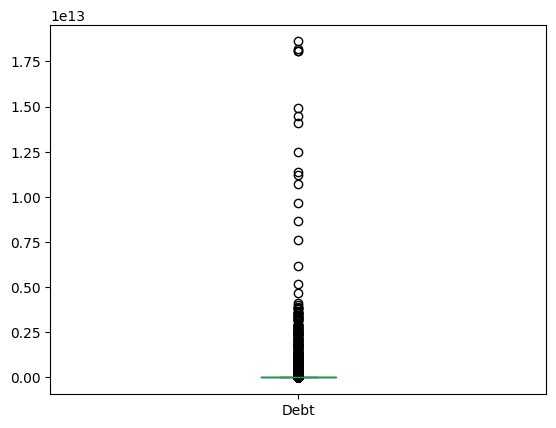

In [118]:
df_final["Debt"].plot(kind="box")

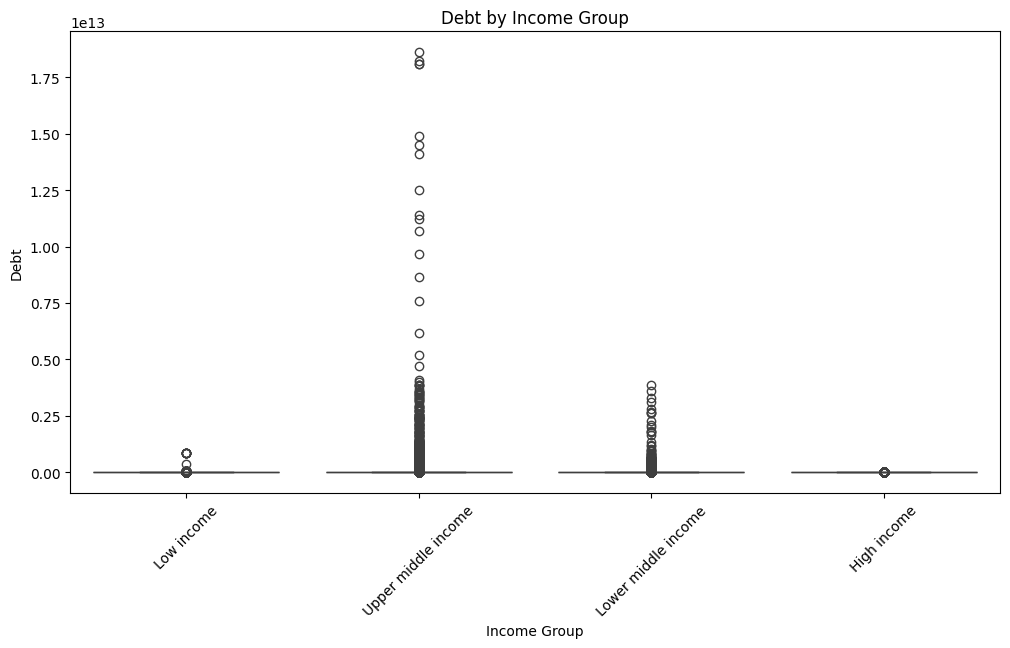

In [119]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df_final, x="Income Group", y="Debt")

plt.xticks(rotation=45)
plt.title("Debt by Income Group")
plt.show()

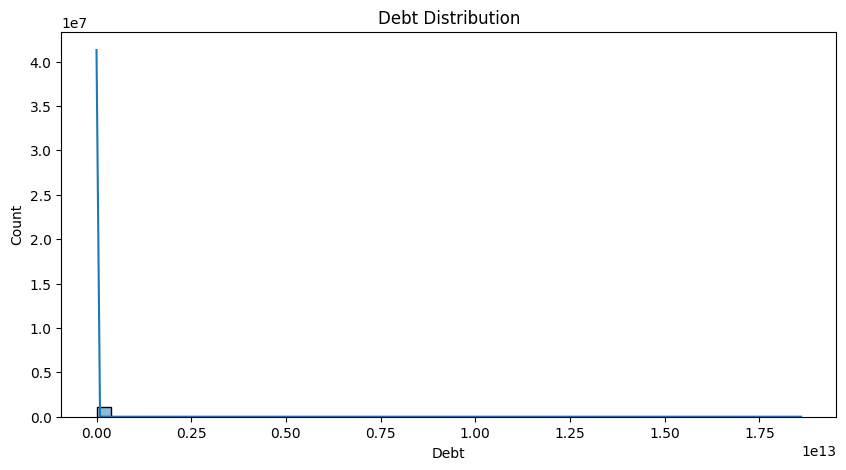

In [120]:
plt.figure(figsize=(10,5))
sns.histplot(df_final["Debt"], bins=50, kde=True)
plt.title("Debt Distribution")
plt.show()

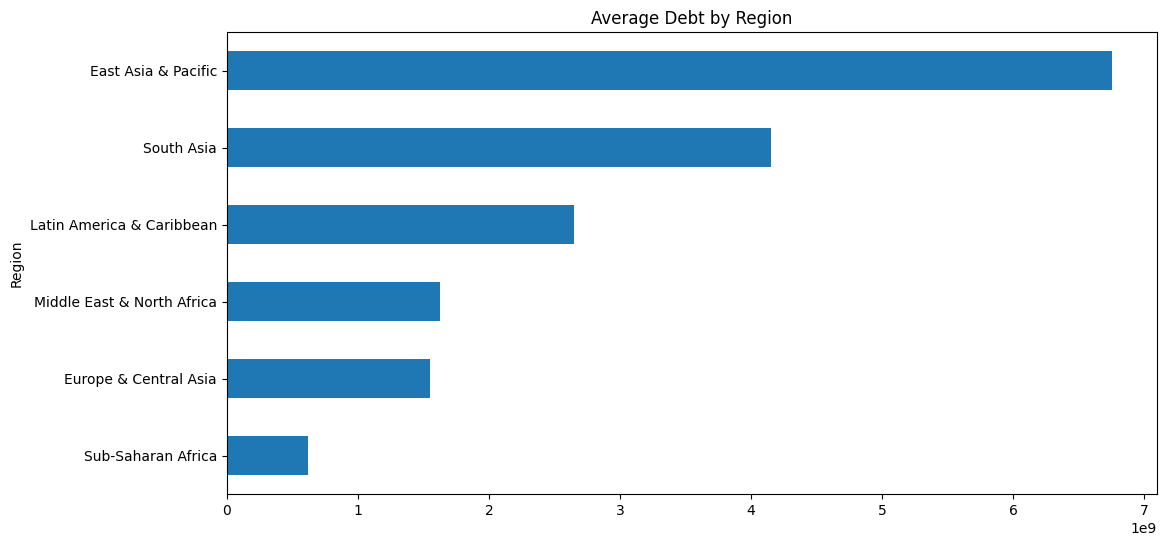

In [121]:
region_debt = df_final.groupby("Region")["Debt"].mean().sort_values()

plt.figure(figsize=(12,6))
region_debt.plot(kind="barh")
plt.title("Average Debt by Region")
plt.show()

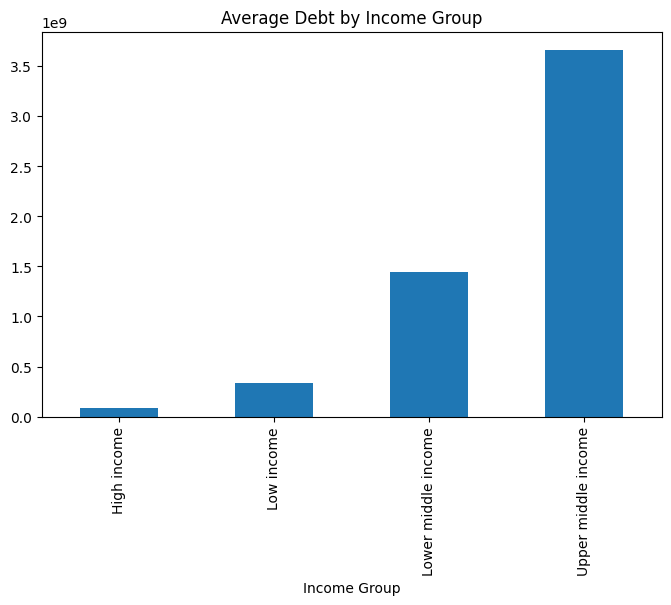

In [122]:
income_debt = df_final.groupby("Income Group")["Debt"].mean()

income_debt.plot(kind="bar", figsize=(8,5))
plt.title("Average Debt by Income Group")
plt.show()

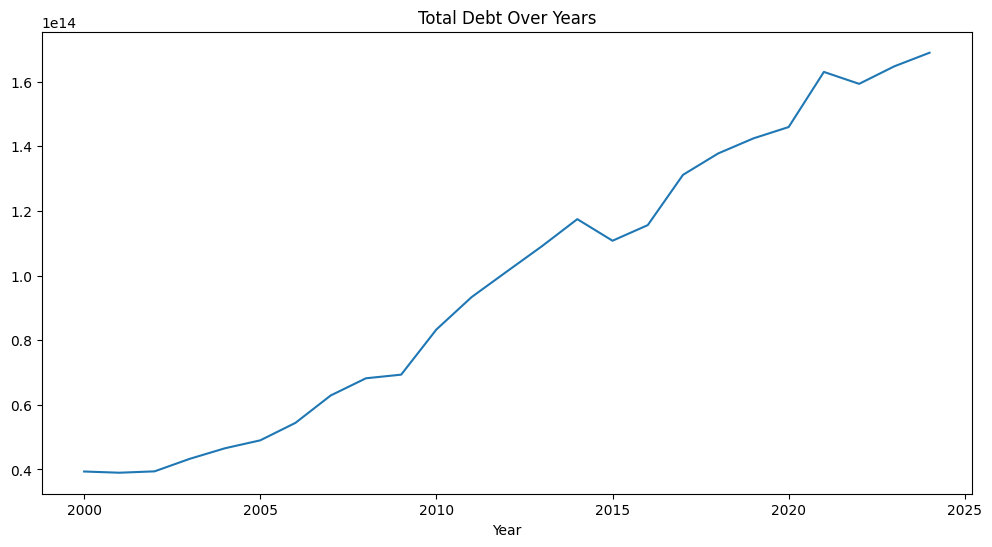

In [123]:
year_trend = df_final.groupby("Year")["Debt"].sum()

plt.figure(figsize=(12,6))
year_trend.plot()
plt.title("Total Debt Over Years")
plt.show()

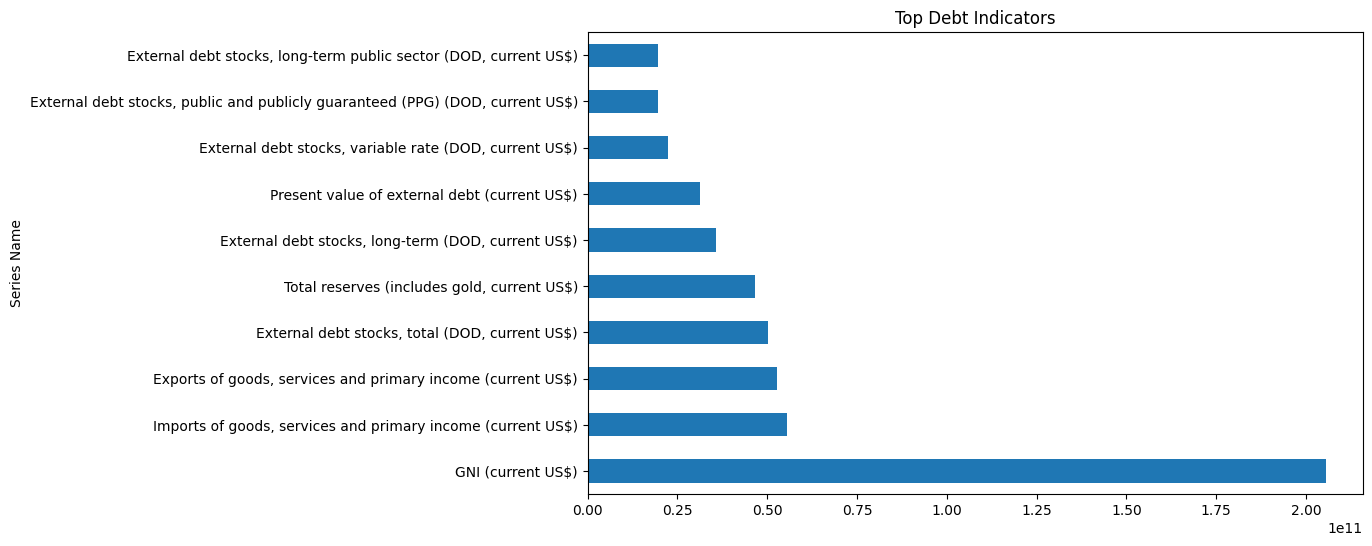

In [124]:
top_series = df_final.groupby("Series Name")["Debt"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_series.plot(kind="barh")
plt.title("Top Debt Indicators")
plt.show()

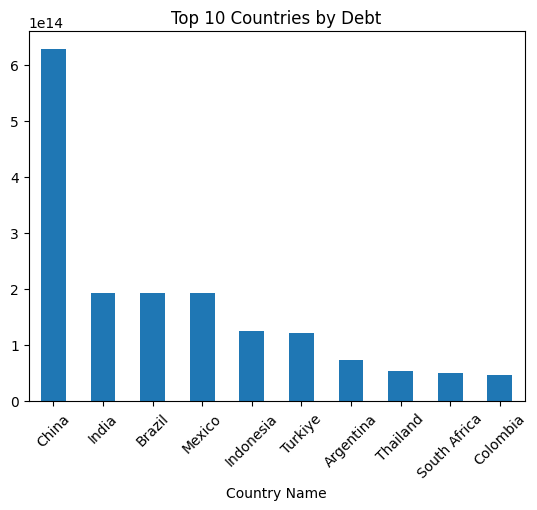

In [125]:
top_countries = df_final.groupby("Country Name")["Debt"].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Debt")
plt.xticks(rotation=45)
plt.show()

In [126]:
df_final[["Year", "Debt"]].corr()

,Year,Debt
Year,1.00000,0.01691
Debt,0.01691,1.00000


In [127]:
df_final["Country Name"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Armenia', 'Azerbaijan', 'Bangladesh', 'Belarus', 'Belize',
       'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon',
       'Central African Republic', 'China', 'Colombia', 'Comoros',
       'Congo, Rep.', "Cote d'Ivoire", 'Dominican Republic', 'Ecuador',
       'Egypt, Arab Rep.', 'El Salvador', 'Eswatini', 'Fiji',
       'Gambia, The', 'Georgia', 'Ghana', 'Guatemala', 'Guinea', 'Guyana',
       'Honduras', 'India', 'Indonesia', 'Iran, Islamic Rep.', 'Iraq',
       'Jamaica', 'Jordan', 'Kazakhstan', 'Kenya', 'Kyrgyz Republic',
       'Lao PDR', 'Lebanon', 'Lesotho', 'Madagascar', 'Malawi',
       'Maldives', 'Mali', 'Mauritania', 'Mauritius', 'Mexico', 'Moldova',
       'Mongolia', 'Montenegro', 'Morocco', 'Mozambique', 'Myanmar',
       'Nepal', 'Nicaragua', 'Niger', 'Nigeria', 'North Macedonia',
       'Pakistan', 'Paragu

In [128]:
df_final["Region"].unique()

array(['Middle East & North Africa', 'Europe & Central Asia',
       'Sub-Saharan Africa', 'Latin America & Caribbean', 'South Asia',
       'East Asia & Pacific'], dtype=object)

In [129]:
country_debt = (
    df_final
    .groupby("Country Name")["Debt"]
    .sum()
    .sort_values(ascending=False)
)

print(country_debt.head(10))

Country Name
China           6.283012e+14
India           1.934769e+14
Brazil          1.921153e+14
Mexico          1.920731e+14
Indonesia       1.243705e+14
Turkiye         1.215433e+14
Argentina       7.361376e+13
Thailand        5.390440e+13
South Africa    5.019431e+13
Colombia        4.706364e+13
Name: Debt, dtype: float64


In [130]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1090800 entries, 0 to 1487449
Data columns (total 10 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Country Name      1090800 non-null  object 
 1   Country Code      1090800 non-null  object 
 2   Series Name       1090800 non-null  object 
 3   Series Code       1090800 non-null  object 
 4   Year              1090800 non-null  int64  
 5   Debt              1090800 non-null  float64
 6   Region            1090800 non-null  object 
 7   Income Group      1090800 non-null  object 
 8   Lending category  1090800 non-null  object 
 9   System of trade   1090800 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 91.5+ MB


# Country-wise total debt calculation

In [132]:
country_debt = df_final.groupby('Country Name')['Debt'].sum().sort_values(ascending=False)
country_debt

,Debt
Country Name,
China,6.283012e+14
India,1.934769e+14
Brazil,1.921153e+14
Mexico,1.920731e+14
Indonesia,1.243705e+14
...,...
St. Vincent and the Grenadines,2.305402e+11
Samoa,1.908532e+11
Comoros,1.750780e+11


In [133]:
print(df_final.columns.tolist())

['Country Name', 'Country Code', 'Series Name', 'Series Code', 'Year', 'Debt', 'Region', 'Income Group', 'Lending category', 'System of trade']


# Top 10 and Bottom 10 identification

In [134]:
top_10 = country_debt.head(10)
bottom_10 = country_debt.tail(10)

print("Top 10 Countries by Debt:")
print(top_10)

print("="*55)

print("Bottom 10 Countries by Debt:")
print(bottom_10)

Top 10 Countries by Debt:
Country Name
China           6.283012e+14
India           1.934769e+14
Brazil          1.921153e+14
Mexico          1.920731e+14
Indonesia       1.243705e+14
Turkiye         1.215433e+14
Argentina       7.361376e+13
Thailand        5.390440e+13
South Africa    5.019431e+13
Colombia        4.706364e+13
Name: Debt, dtype: float64
Bottom 10 Countries by Debt:
Country Name
Gambia, The                       4.787061e+11
Burundi                           4.768780e+11
Central African Republic          3.998909e+11
St. Lucia                         3.596237e+11
Timor-Leste                       2.330715e+11
St. Vincent and the Grenadines    2.305402e+11
Samoa                             1.908532e+11
Comoros                           1.750780e+11
Solomon Islands                   1.673062e+11
Sao Tome and Principe             1.364182e+11
Name: Debt, dtype: float64


# Percentage contribution

In [135]:
total_global = df_final['Debt'].sum()
country_pct = (country_debt / total_global * 100).round(2)
country_pct

,Debt
Country Name,
China,25.58
India,7.88
Brazil,7.82
Mexico,7.82
Indonesia,5.06
...,...
St. Vincent and the Grenadines,0.01
Samoa,0.01
Comoros,0.01


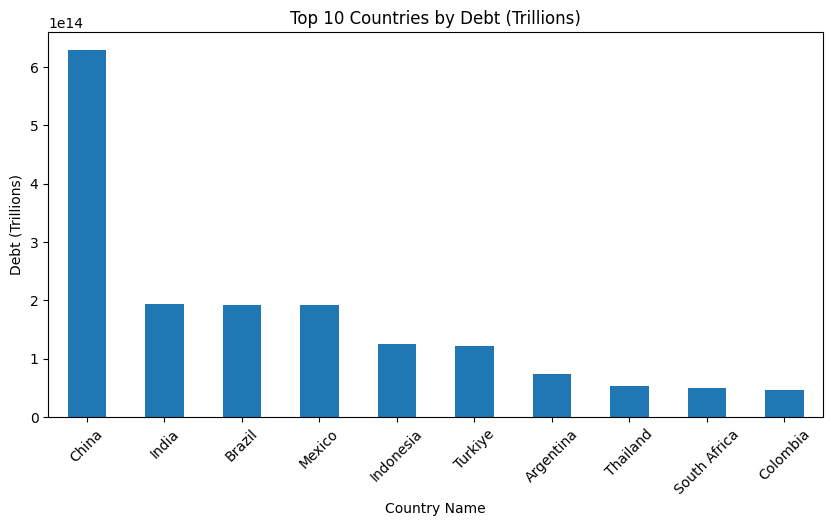

In [136]:
top_10.plot(kind='bar', figsize=(10,5), title="Top 10 Countries by Debt (Trillions)")
plt.ylabel("Debt (Trillions)")
plt.xticks(rotation=45)
plt.show()

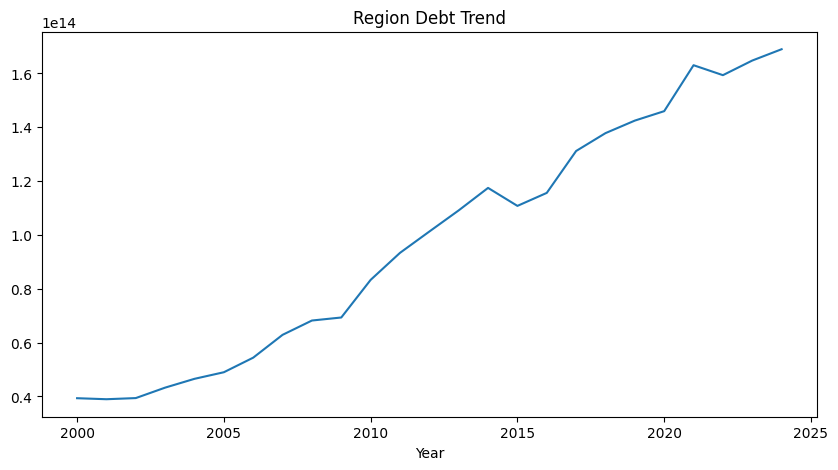

In [137]:
df_final.groupby("Year")["Debt"].sum().plot(figsize=(10,5))
plt.title("Region Debt Trend")
plt.show()

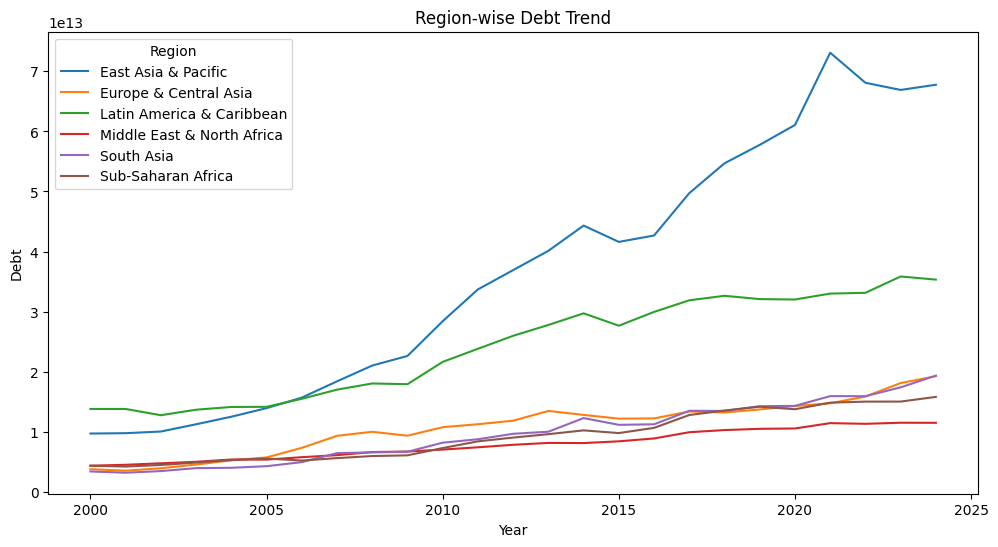

In [138]:
region_trend = df_final.groupby(["Year", "Region"])["Debt"].sum().unstack()

region_trend.plot(figsize=(12,6))
plt.title("Region-wise Debt Trend")
plt.xlabel("Year")
plt.ylabel("Debt")
plt.legend(title="Region")
plt.show()

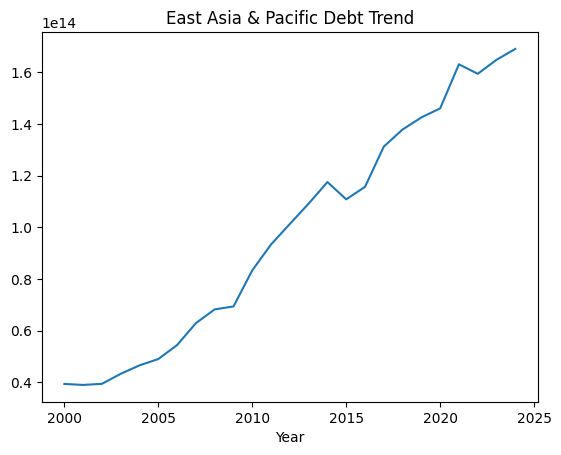

In [139]:
df_final[df_final["Region"] == "East Asia & Pacific"]

df_final.groupby("Year")["Debt"].sum().plot()
plt.title("East Asia & Pacific Debt Trend")
plt.show()

In [140]:
df_final.sample(5)

,Country Name,Country Code,Series Name,Series Code,Year,Debt,Region,Income Group,Lending category,System of trade
291160,"Congo, Rep.",COG,"PRVG, commercial banks (DIS, current US$)",DT.DIS.PCBK.PRVG.CD,2010,0.000000e+00,Sub-Saharan Africa,Lower middle income,Blend,General trade system
143654,Bolivia,BOL,"Net transfers on external debt, private guaran...",DT.NTR.PRPG.CD,2004,0.000000e+00,Latin America & Caribbean,Lower middle income,IBRD,General trade system
66794,Armenia,ARM,"PPG, IDA (NTR, current US$)",DT.NTR.MIDA.CD,2019,0.000000e+00,Europe & Central Asia,Upper middle income,IBRD,General trade system
478703,Georgia,GEO,Present value of external debt (current US$),DT.DOD.PVLX.CD,2003,7.808294e+09,Europe & Central Asia,Upper middle income,IBRD,General trade system
11505,Albania,ALB,"CB, bilateral concessional (DOD, current US$)",DT.DOD.BLTC.CB.CD,2005,1.942668e+07,Europe & Central Asia,Upper middle income,IBRD,Special trade system


In [141]:
df_final.shape

(1090800, 10)

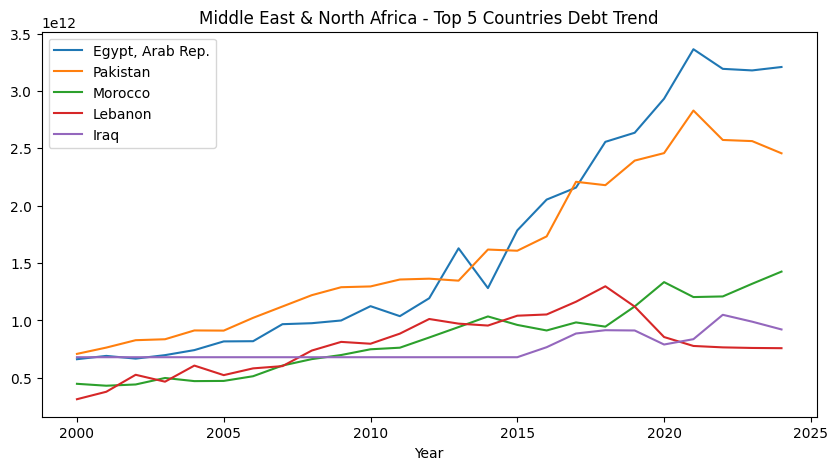

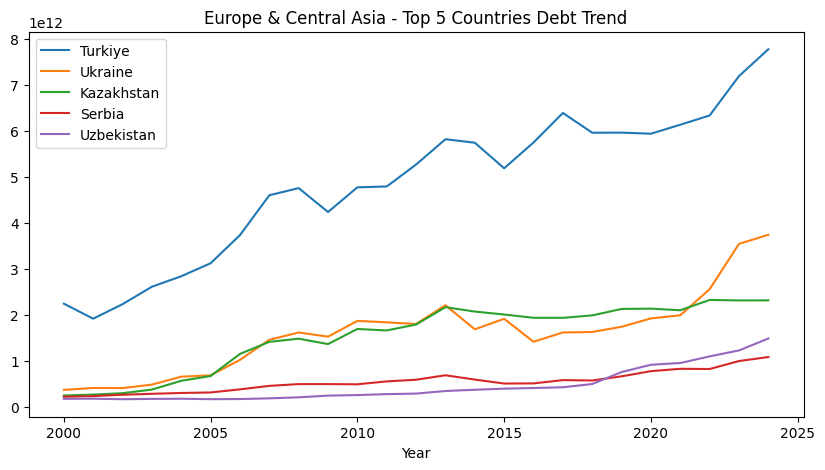

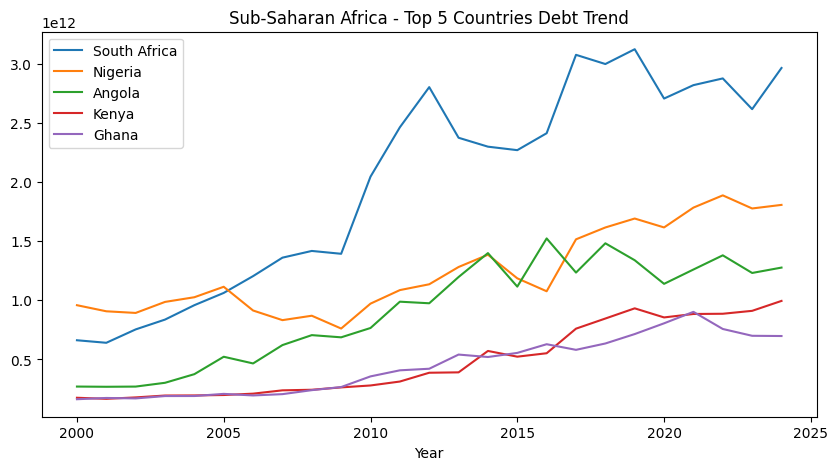

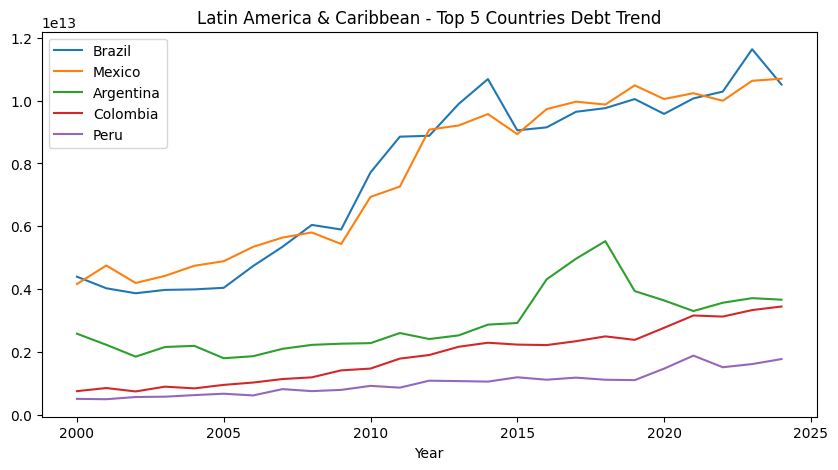

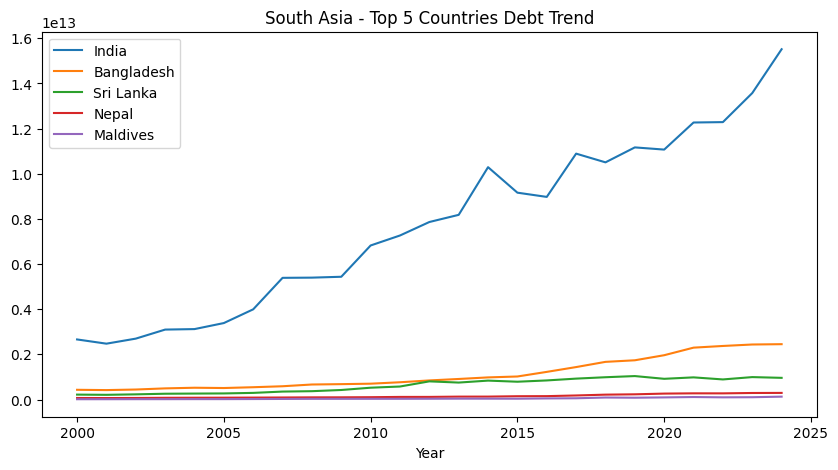

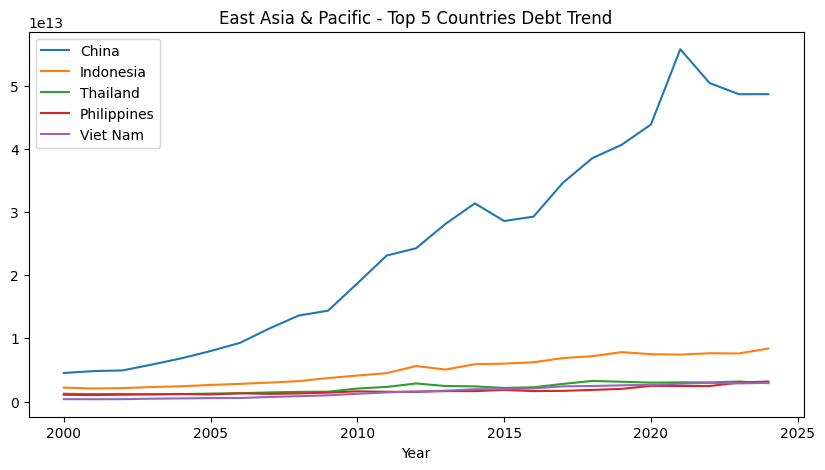

In [147]:
for region in df_final["Region"].unique():
    df_region = df_final[df_final["Region"] == region]

    # Top 5 countries by total debt
    top_countries = (
        df_region.groupby("Country Name")["Debt"]
        .sum()
        .nlargest(5)
        .index
    )

    plt.figure(figsize=(10,5))

    for country in top_countries:
        df_country = df_region[df_region["Country Name"] == country]
        df_country.groupby("Year")["Debt"].sum().plot(label=country)

    plt.title(f"{region} - Top 5 Countries Debt Trend")
    plt.legend()
    plt.show()